## Initialization Libraries.

In [2]:
# Import required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

## Load the Dataset

In [ ]:
# Load the dataset
df = pd.read_csv('employee_performance.csv')
df

,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
0,1001,HR,30,44048,8,8,78,No
1,1002,Finance,29,52409,10,8,94,Yes
2,1003,Finance,43,73583,9,8,90,Yes
3,1004,IT,28,52000,2,8,83,No
4,1005,HR,33,36117,2,9,100,No
...,...,...,...,...,...,...,...,...
3995,4996,Marketing,44,43458,4,6,67,No
3996,4997,IT,35,55774,9,7,64,No
3997,4998,Sales,31,38862,10,6,95,Yes
3998,4999,HR,29,75582,4,7,93,No


In [ ]:
# Display first 5 rows
df.head()

,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
0,1001,HR,30,44048,8,8,78,No
1,1002,Finance,29,52409,10,8,94,Yes
2,1003,Finance,43,73583,9,8,90,Yes
3,1004,IT,28,52000,2,8,83,No
4,1005,HR,33,36117,2,9,100,No


In [11]:
# Display last 5 rows
df.tail()

,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
3995,4996,Marketing,44,43458,4,6,67,No
3996,4997,IT,35,55774,9,7,64,No
3997,4998,Sales,31,38862,10,6,95,Yes
3998,4999,HR,29,75582,4,7,93,No
3999,5000,Sales,22,55503,1,6,87,No


In [12]:
# Display Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         4000 non-null   int64 
 1   Department          4000 non-null   object
 2   Age                 4000 non-null   int64 
 3   Salary              4000 non-null   int64 
 4   Projects_Completed  4000 non-null   int64 
 5   Working_Hours       4000 non-null   int64 
 6   Performance_Score   4000 non-null   int64 
 7   Promotion_Status    4000 non-null   object
dtypes: int64(6), object(2)
memory usage: 250.1+ KB


In [14]:
# Display Dtypes
df.dtypes

Employee_ID            int64
Department            object
Age                    int64
Salary                 int64
Projects_Completed     int64
Working_Hours          int64
Performance_Score      int64
Promotion_Status      object
dtype: object

In [15]:
# Describe the dataset
df.describe()

,Employee_ID,Age,Salary,Projects_Completed,Working_Hours,Performance_Score
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,3000.500000,33.398000,57064.591750,5.456750,7.974250,74.991000
std,1154.844867,6.808023,13012.938972,2.866301,1.411412,14.715963
min,1001.000000,22.000000,35005.000000,1.000000,6.000000,50.000000
25%,2000.750000,28.000000,45965.500000,3.000000,7.000000,62.000000
50%,3000.500000,33.000000,56852.000000,5.000000,8.000000,74.000000
75%,4000.250000,39.000000,68197.500000,8.000000,9.000000,88.000000
max,5000.000000,45.000000,79995.000000,10.000000,10.000000,100.000000


## Step 1 : Central Tendency & Dispersion

In [ ]:
# Calculate Central Tendency
print("Central Tendency (Salary):")

# Mean
salary_mean = np.mean(df["Salary"])
# Median
salary_median = np.median(df["Salary"])
# Mode
salary_mode = df["Salary"].mode()[0]

print("Mean:", salary_mean)
print("Median:", salary_median)
print("Mode:", salary_mode)

Central Tendency (Salary):
Mean: 57064.59175
Median: 56852.0
Mode: 43436


In [17]:
# Calculate Dispersion
print("Measures of Dispersion (Projects_Completed):")

# Range
projects_completed_range = np.ptp(df["Projects_Completed"])
# Variance
projects_completed_variance = np.var(df["Projects_Completed"])
# Standard Deviation
projects_completed_std = np.std(df["Projects_Completed"])

print("Range:",projects_completed_range)
print("Variance:",projects_completed_variance)
print("Standard Deviation:",projects_completed_std)


Measures of Dispersion (Projects_Completed):
Range: 9
Variance: 8.2136294375
Standard Deviation: 2.865943027608888


## Step 2 : Probability & Events

In [19]:
# Calculate Probability of employees getting promoted
prob_promotion = (df["Promotion_Status"] == "Yes").mean()
print("Probability of Employees getting Promoted:", prob_promotion)

Probability of Employees getting Promoted: 0.18625


In [21]:
# Contingency Table
cont_table = pd.crosstab(df["Department"], df["Promotion_Status"])
cont_table

Promotion_Status,No,Yes
Department,,
Finance,629,159
HR,640,144
IT,673,143
Marketing,658,151
Sales,655,148


In [ ]:
# Conditional Probability    P(Promotion Status | Performance Score > 80)

high_perf = df[df["Performance_Score"] > 80]
cond_prob = (high_perf["Promotion_Status"] == "Yes").mean()

print("P(Promotion | Score > 80):", cond_prob)

P(Promotion | Score > 80): 0.48251295336787564


## Step 3: Distribution & Visualization

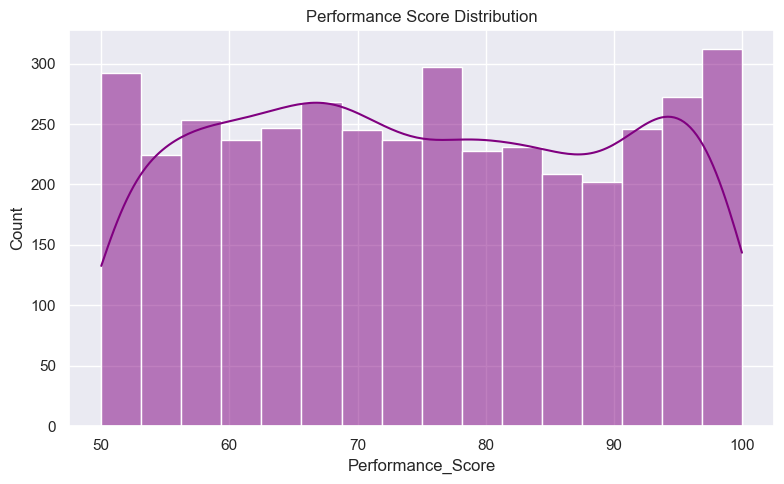

In [28]:
# Histogram + Gaussian Curve

sns.set(style="darkgrid")
plt.figure(figsize=(8, 5))
sns.histplot(df["Performance_Score"], kde=True, color="purple")
plt.title("Performance Score Distribution")
plt.ylabel("Count")
plt.xlabel("Performance_Score")
plt.tight_layout()
plt.show()


In [30]:
# Skewness & Kurtosis (Salary)

skewness = df["Salary"].skew()
kurtosis = df["Salary"].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 0.03361864822440312
Kurtosis: -1.1935890278091836


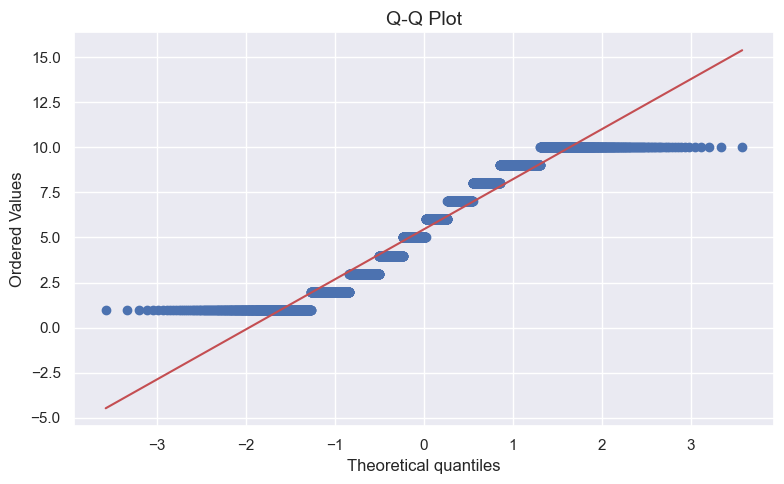

In [36]:
# Q-Q Plot of Project_Completed

sns.set(style="darkgrid")
plt.figure(figsize=(8,5))
stats.probplot(df["Projects_Completed"], dist="norm", plot=plt)
plt.title("Q-Q Plot", fontsize = 14)
plt.tight_layout()
plt.show()


## Step 4: Linear Algebra
### First 5 Employees Vectors

In [ ]:
# First 5 Employees Vectors

vectors = df[["Projects_Completed", "Working_Hours"]].head().values

v1 = vectors[0]
v2 = vectors[1]

print("Vector 1:", v1)
print("Vector 2:", v2)

Vector 1: [8 8]
Vector 2: [10  8]


In [ ]:
# Dot Product

dot_product = np.dot(v1, v2)
print("Dot Product:", dot_product)

Dot Product: 144


In [ ]:
# Norm 1 & Norm 2

norm1 = np.linalg.norm(v1)
norm2 = np.linalg.norm(v2)

print("Norm of Vector 1:", norm1)
print("Norm of Vector 2:", norm2)

Norm of v1: 11.313708498984761
Norm of v2: 12.806248474865697


In [42]:
# Angle Between Vectors

angle = np.arccos(dot_product / (norm1 * norm2))
angle_deg = np.degrees(angle)

print("Angle (degrees) between two Vectors:", angle_deg)

Angle (degrees) between two Vectors: 6.340191745909966


## Key Insights 

### 1️. High Performance = High Promotion Chance

- #### Employees with Performance Score > 80 have a significantly higher probability of promotion.
- #### This shows that performance is the main deciding factor in promotions.

### 2️. Projects Completed Matters

- #### Employees who completed more than 5–6 projects are more likely to get promoted.
- #### Promotions are based not just on score but also on productivity/output.

### 3️. Salary Distribution Insight

- #### Salary shows slight positive skewness (right-skewed).
- #### Most employees earn mid-range salaries, while a few earn very high salaries.

### 4️. Working Hours vs Performance

- #### Employees working more hours (8–10 hrs) tend to have better performance scores.
- #### Indicates a positive relationship between effort and performance.

### 5️. Department-wise Trend

- #### Departments like Sales and Finance generally have:

##### --> Higher project completion
##### --> Higher promotion rate

- Suggests these departments are more target/result-driven.